In [1]:
import torch.nn as nn
from transformers import CLIPModel
import matplotlib.pyplot as plt
import pickle
from torch.utils.data import Dataset
import numpy as np
import json
import torch
import os
from tqdm.notebook import tqdm
import torch.nn.functional as F

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
image_set = "farfetch"
text_set = "nemotron"
mode = "test"
embedding_mode = "clip"

In [3]:
if mode == "test":
    with open(f'../data_preparation/{text_set}/{embedding_mode}/test_persona_embeddings.pkl', 'rb') as f:
        test_embeddings = pickle.load(f)
    with open(f'../generate_test_set/{image_set + "+" + text_set}/test_indices.json', "r") as f:
        test_indices = json.load(f)
    with open(f'../data_preparation/{image_set}/pixel_values_test.pkl', 'rb') as f:
        test_pixel_values = torch.load(f, weights_only=False)
    with open(f'../data_preparation/{text_set}/test_personas.json', 'r') as f:
        personas = json.load(f)
    with open(f'../data_preparation/{image_set}/images_test.pkl', 'rb') as f:
        images = pickle.load(f)
elif mode == "val":
    with open(f'../data_preparation/{text_set}/{embedding_mode}/validation_persona_embeddings.pkl', 'rb') as f:
        test_embeddings = pickle.load(f)
    with open(f'../generate_test_set/{image_set + "+" + text_set}/val_indices.json', "r") as f:
        test_indices = json.load(f)
    with open(f'../data_preparation/{image_set}/pixel_values_val.pkl', 'rb') as f:
        test_pixel_values = torch.load(f, weights_only=False)
    with open(f'../data_preparation/{text_set}/validation_personas.json', 'r') as f:
        personas = json.load(f)
    with open(f'../data_preparation/{image_set}/images_val.pkl', 'rb') as f:
        images = pickle.load(f)

In [4]:
class PersonaImageDataset(Dataset):
    def __init__(self, personas, images, image_indices, scores, transform=None):
        self.personas = personas
        self.images = images
        self.scores = scores
        self.image_indices = image_indices
        self.transform = transform

    def __len__(self):
        return len(self.image_indices)

    def __getitem__(self, idx):
        img = self.images[self.image_indices[idx]]
        persona = self.personas[idx]
        score = self.scores[idx]

        if self.transform:
            img = self.transform(img)

        return (persona, img) , score

In [5]:
device = "cuda:1"

In [6]:
if embedding_mode == "openai":

    class FashionCLIPImageEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.vision_encoder = CLIPModel.from_pretrained(
                "patrickjohncyh/fashion-clip"
            ).vision_model

            self.projection = nn.Linear(768, 1536)

        def forward(self, pixel_values):
            x = self.vision_encoder(pixel_values).pooler_output
            x = self.projection(x)
            return x

elif embedding_mode == "clip":

    class FashionCLIPImageEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            # Load the full model temporarily to extract projection weights
            full_clip_model = CLIPModel.from_pretrained(
                "patrickjohncyh/fashion-clip"
            )

            # Extract vision encoder
            self.vision_encoder = full_clip_model.vision_model

            # Extract the visual projection layer weights
            self.projection = nn.Linear(768, 512, bias=False)
            self.projection.weight.data = (
                full_clip_model.visual_projection.weight.data.clone()
            )

            # Delete the full model to save memory
            del full_clip_model

        def forward(self, pixel_values):
            x = self.vision_encoder(pixel_values).pooler_output
            x = self.projection(x)
            return x

model = FashionCLIPImageEncoder().to(device)

In [7]:
import torch

def run_model_in_batches(model, pixel_values, batch_size=32, device='cuda'):
    model.eval()
    results = []

    with torch.no_grad():
        for i in range(0, len(pixel_values), batch_size):
            batch = pixel_values[i:i + batch_size].to(device)
            output = model(batch)
            results.append(output)

    # Concatenate outputs if they are tensors
    if isinstance(results[0], torch.Tensor):
        results = torch.cat(results, dim=0)
    
    return results

In [8]:
medians = []
means = []
sorted_indices_list = []

In [9]:
len(test_indices)

50

In [10]:
# state_dict = torch.load(f'{image_set + "+" + text_set}/{embedding_mode}/drift_weights/model_weights{-1}.pth', map_location=torch.device("cuda"))
# model.load_state_dict(state_dict)
# model.eval()
# output = model(test_pixel_values[0:6].to("cuda:1"))
# print(output)
# step_n = 0
# model.eval()
# print(step_n -1)
# state_dict = torch.load(f'{image_set + "+" + text_set}/{embedding_mode}/drift_weights/model_weights{-1}.pth', map_location=torch.device("cuda"))
# model.load_state_dict(state_dict, strict=False)
# test_results = run_model_in_batches(model, test_pixel_values, batch_size=8, device=device).float()
# print(test_results)

#When batch size goes from 5 -> 6 the first float increases by 0.001 inexplicably.

  0%|          | 0/50 [00:00<?, ?it/s]

top 5:  0.12000000000000001 top 20:  0.18 top 100:  0.27999999999999997 top 500:  0.5200000000000001
Mean rank:  0.830751953125 Median rank:  0.89306640625 Top quartile:  0.982666015625


C:\Users\ericy\AppData\Local\Temp\ipykernel_24952\3785381979.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_indices = torch.tensor(test_indices)


  0%|          | 0/50 [00:00<?, ?it/s]

top 5:  0.12000000000000001 top 20:  0.18 top 100:  0.27999999999999997 top 500:  0.5200000000000001
Mean rank:  0.830751953125 Median rank:  0.89306640625 Top quartile:  0.982666015625


...

top 5:  0.12000000000000001 top 20:  0.14 top 100:  0.4200000000000001 top 500:  0.6200000000000002
Mean rank:  0.87369140625 Median rank:  0.9329833984375 Top quartile:  0.988037109375


  0%|          | 0/50 [00:00<?, ?it/s]

top 5:  0.12000000000000001 top 20:  0.14 top 100:  0.4200000000000001 top 500:  0.6200000000000002
Mean rank:  0.873857421875 Median rank:  0.934326171875 Top quartile:  0.98785400390625


  0%|          | 0/50 [00:00<?, ?it/s]

top 5:  0.12000000000000001 top 20:  0.14 top 100:  0.4200000000000001 top 500:  0.6600000000000003
Mean rank:  0.8739013671875 Median rank:  0.9295654296875 Top quartile:  0.9869384765625


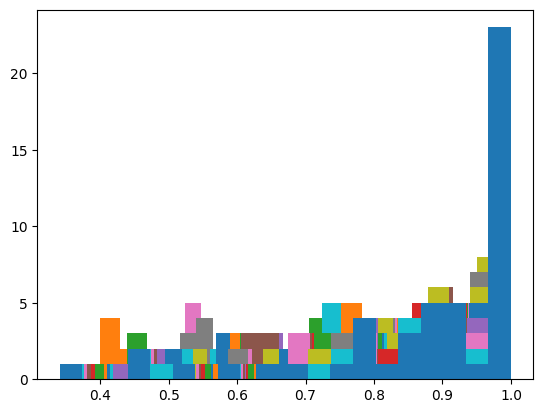

In [11]:
datasets = []
for step_n in range(len(os.listdir(f'{image_set + "+" + text_set}/{embedding_mode}/drift_weights'))):
    model.eval()
    state_dict = torch.load(f'{image_set + "+" + text_set}/{embedding_mode}/drift_weights/model_weights{step_n-1}.pth', map_location=torch.device("cuda"))
    model.load_state_dict(state_dict, strict=False)
    test_results = run_model_in_batches(model, test_pixel_values, batch_size=32, device=device).float()
    test_embeddings = test_embeddings.to(device).float()
    test_results_norm = F.normalize(test_results, p=2, dim=1)
    test_embeddings_norm = F.normalize(test_embeddings, p=2, dim=1)
    test_cosine_sim = torch.matmul(test_results_norm, test_embeddings_norm.T)
    test_sorted_values, test_sorted_indices = torch.sort(test_cosine_sim, dim=0)
    test_indices = torch.tensor(test_indices)
    test_score = 0
    top_5 = 0
    top_20 = 0
    top_100 = 0
    top_500 = 0
    L = []

    sorted_indices_list.append(test_sorted_indices.cpu().numpy())

    for i in tqdm(range(len(test_indices))):
        test_sorted_indices_column = test_sorted_indices[:, i]
        n = test_sorted_indices_column.tolist().index(test_indices[i])
        L.append((n / len(test_sorted_indices_column)))
        if (len(test_sorted_indices_column)- n) < 5:
            top_5 += 1/len(test_indices)
        if (len(test_sorted_indices_column)- n) < 20:
            top_20 += 1/len(test_indices)
        if (len(test_sorted_indices_column)- n) < 100:
            top_100 += 1/len(test_indices)
        if (len(test_sorted_indices_column)- n) < 500:
            top_500 += 1/len(test_indices)

    print("top 5: ", top_5, "top 20: ", top_20, "top 100: ", top_100, "top 500: ", top_500)
    print("Mean rank: ", np.mean(L), "Median rank: ", np.median(L), "Top quartile: ", np.percentile(L, 75))
    _ = plt.hist(L, bins=20)

    medians.append(np.median(L))
    means.append(np.mean(L))

    datasets.append(L)

Carmen, a 46-year-old air traffic control specialist, balances her high-stress job with creative outlets like painting and yoga, while her competitive nature and love for history shape her worldview


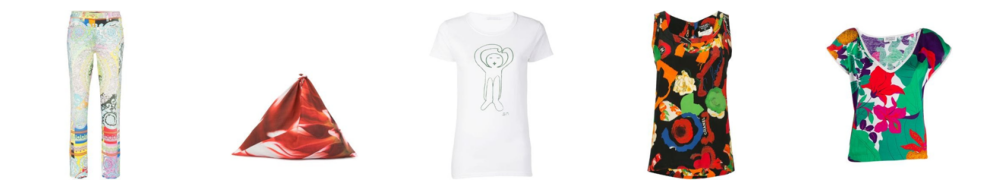

In [12]:
n = 1
print(personas[n])

stop_step = 0

img_list = [images[k] for k in sorted_indices_list[stop_step][:, n][::-1]]

num_images = 5
cols = 10  # images per row
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(cols * 2, rows * 2))  # adjust size as needed

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_list[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()
bins = np.linspace(0, 1, 21)
hist = ax.hist([], bins=bins)[2]  # Initialize empty bar container

def init():
    for bar in hist:
        bar.set_height(0)
    return hist

def update(frame):
    ax.clear()  # Optional: clear axis for different scales
    ax.hist(datasets[frame], bins=bins, color='skyblue', edgecolor='black')
    ax.set_ylim(0, 40)
    ax.set_title(f'Frame {frame}')
    return ax.patches

anim = FuncAnimation(fig, update, frames=len(datasets), init_func=init, blit=False, repeat=False)

plt.close()  # Prevent static plot from showing
HTML(anim.to_jshtml())  # Show animation in notebook


In [14]:
import json
with open(f'../other_approaches/scores.json', 'r') as f:
    scores = json.load(f)

median_score = scores[image_set + "+" + text_set][0]
mean_score = scores[image_set + "+" + text_set][1]

In [15]:
data = [{"step_n": i, "median": medians[i], "mean": means[i]} for i in range(len(medians))]

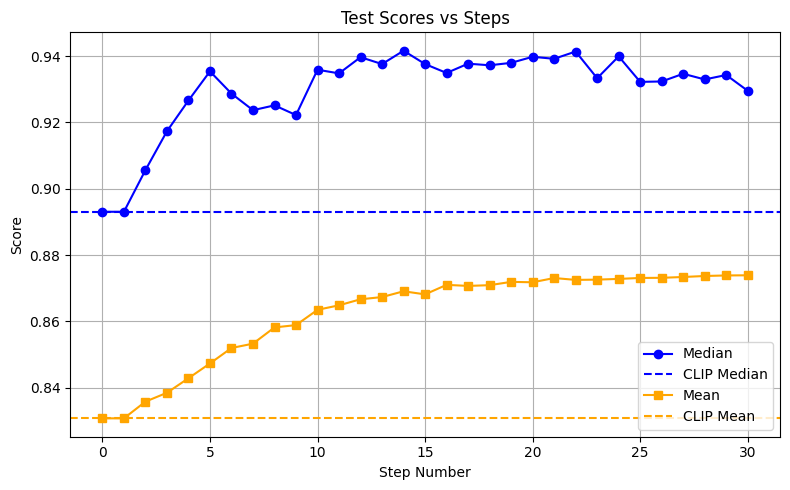

In [16]:
import json
import matplotlib.pyplot as plt

plot_median = True

# Extract data
steps = [item['step_n'] for item in data]
medians = [item['median'] for item in data]
means = [item['mean'] for item in data]

# Plotting
plt.figure(figsize=(8, 5))
if plot_median:
    plt.plot(steps, medians, marker='o', label='Median', color = 'blue')
    plt.axhline(y=medians[0], color='blue', linestyle='--', label='CLIP Median')
plt.plot(steps, means, marker='s', label='Mean', color = 'orange')
plt.axhline(y=means[0], color='orange', linestyle='--', label='CLIP Mean')

plt.title('Test Scores vs Steps')
plt.xlabel('Step Number')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


In [17]:
if mode == "val":
    max_mean = 0
    counter = 0
    for i, mean in enumerate(means):
        if mean > max_mean:
            max_mean = mean
            counter = 0
        else:
            counter += 1
        print(i, "Mean:", mean, "Max Mean:", max_mean, "Counter:", counter)
        if counter >= 5:
            break
    print(i)

In [18]:
early_stopping_path = "early_stopping.json"
key = image_set + "+" + text_set

if mode == "val":
    print(f"Setting early stopping epoch for {key} to {i}")
    if os.path.exists(early_stopping_path):
        with open(early_stopping_path, "r") as f:
            early_stopping_data = json.load(f)
    else:
        early_stopping_data = {}

    early_stopping_data[key] = i

    with open(early_stopping_path, "w") as f:
        json.dump(early_stopping_data, f, indent=2)
else:
    with open(early_stopping_path, "r") as f:
        early_stopping_data = json.load(f)
    if key in early_stopping_data:
        early_stopping_epoch = early_stopping_data[key]
        print(f"Early stopping epoch for {key}: {early_stopping_epoch}")
        print(f"Mean at early stopping: {means[early_stopping_epoch]}")
    else:
        print(f"No early stopping epoch found for {key}")

Early stopping epoch for farfetch+nemotron: 25
Mean at early stopping: 0.8731005859375
